In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
import os
from settings import OUTPUT_FOLDER
from data_generation import parse_blocks, parse_states
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_ranking_frequencies(folder_paths):
    counter = dict()

    for folder_path in folder_paths:
        folder_path = OUTPUT_FOLDER / folder_path
        if not os.path.isdir(folder_path):
            print(f"⚠️ Carpeta no encontrada: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            filepath = os.path.join(folder_path, filename)

            blocks_data = parse_blocks(filepath)
            states_data = parse_states(filepath, blocks_data)

            for state in states_data:
                action_blocks = [action_block.block.block_id for action_block in state.actions]
                selected_block = state.chosen_action.block.block_id

                pos = action_blocks.index(selected_block) + 1
                if pos not in counter:
                    counter[pos] = 1
                else:
                    counter[pos] += 1

    max_pos = max(counter.keys())
    arr_counter = [counter.get(i, 0) for i in range(1, max_pos + 1)]

    return arr_counter

def plot_ranking_frequencies(counter):
    positions = range(1, len(counter) + 1)

    cum_freq = np.cumsum(counter)
    cum_percent = cum_freq / cum_freq[-1] * 100

    plt.figure(figsize=(8, 5))
    plt.plot(positions, cum_percent)
    plt.xlabel("Posición")
    plt.ylabel("Frecuencia acumulada (%)")
    plt.title("Frecuencia acumulada porcentual por posición")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def get_frequency_dataframe(counter):
    result = [(i, counter[i - 1]) for i in range(1, len(counter) + 1)]
    df = pd.DataFrame(result, columns=["Posición", "Frecuencia"])

    total = df["Frecuencia"].sum()
    df["Frecuencia (%)"] = df["Frecuencia"] / total * 100
    df["Frecuencia acumulada"] = np.cumsum(df["Frecuencia"])
    df["Frecuencia acumulada (%)"] = df["Frecuencia acumulada"] / total * 100

    # Orden final de columnas
    df = df[[
        "Posición",
        "Frecuencia (%)",
        "Frecuencia acumulada (%)"
    ]]

    return df

In [ ]:
folders = ["E4A"]

counter = get_ranking_frequencies(folders)

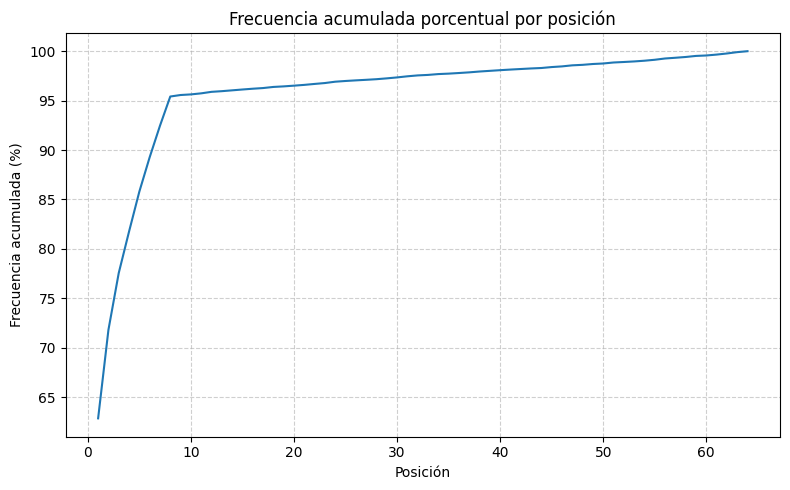

In [11]:
plot_ranking_frequencies(counter)

In [14]:
df = get_frequency_dataframe(counter)
df.head(10)

,Posición,Frecuencia (%),Frecuencia acumulada (%)
0,1,62.844424,62.844424
1,2,8.953626,71.798050
2,3,5.753085,77.551135
3,4,4.197893,81.749028
4,5,4.045754,85.794782
5,6,3.471009,89.265791
6,7,3.189271,92.455063
7,8,2.958246,95.413309
8,9,0.152138,95.565448
9,10,0.061982,95.627430
